In [8]:
import lhapdf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import os

import sys
from pathlib import Path

# Add the parent directory of the current file to sys.path
gen_dir = "/hepusers2/fuscomus/DRToM/"
sys.path.append(gen_dir)

# Now you can import using standard absolute paths from that root
import Generation.functions as fns
import Generation.configuration as cfg

LHAPDF 6.5.6 loading /hepusers2/fuscomus/miniconda3/envs/DRToM/share/LHAPDF/cteq6l1/cteq6l1_0000.dat
cteq6l1 PDF set, member #0, version 4; LHAPDF ID = 10042


LHAPDF 6.5.6 loading /hepusers2/fuscomus/miniconda3/envs/DRToM/share/LHAPDF/cteq6l1/cteq6l1_0000.dat
cteq6l1 PDF set, member #0, version 4; LHAPDF ID = 10042


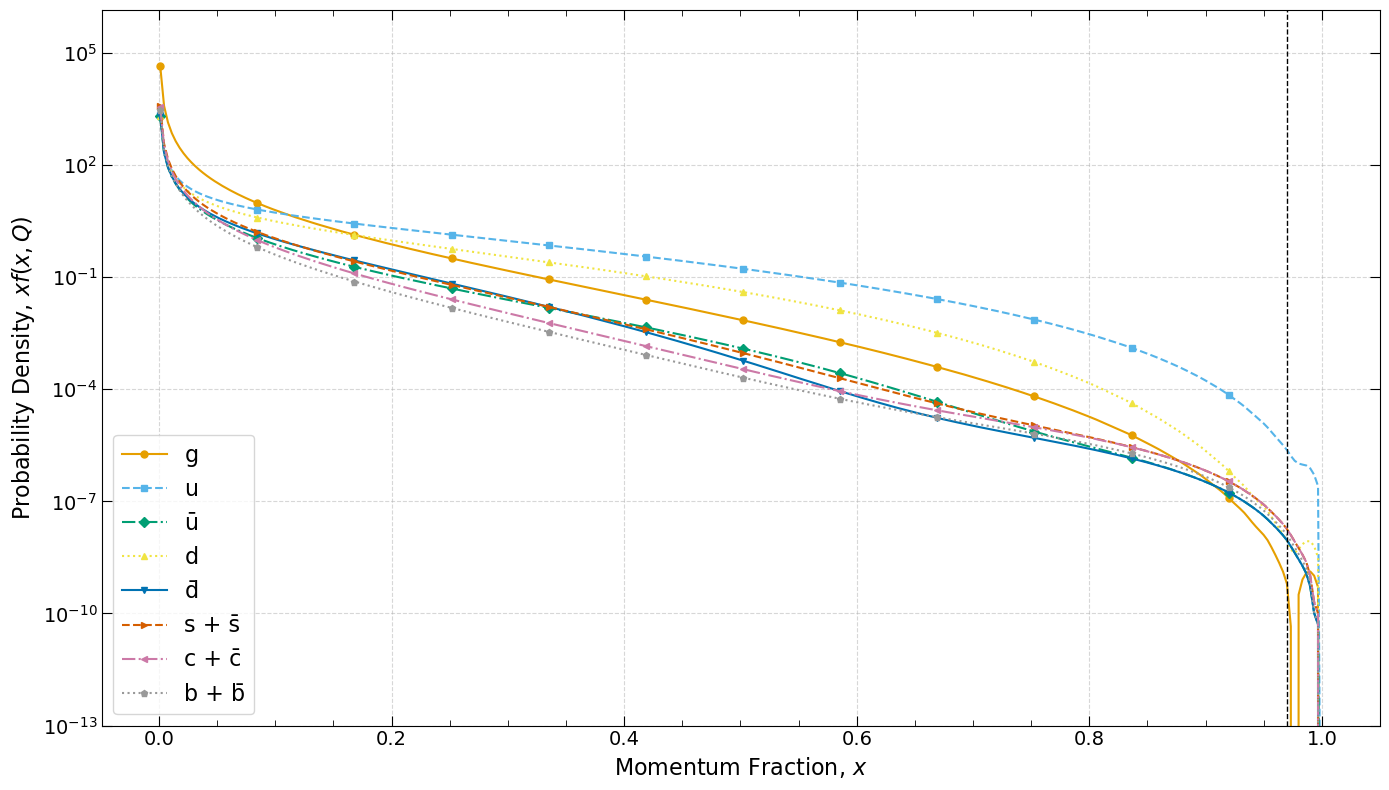

LHAPDF 6.5.6 loading /hepusers2/fuscomus/miniconda3/envs/DRToM/share/LHAPDF/cteq6l1/cteq6l1_0000.dat
cteq6l1 PDF set, member #0, version 4; LHAPDF ID = 10042


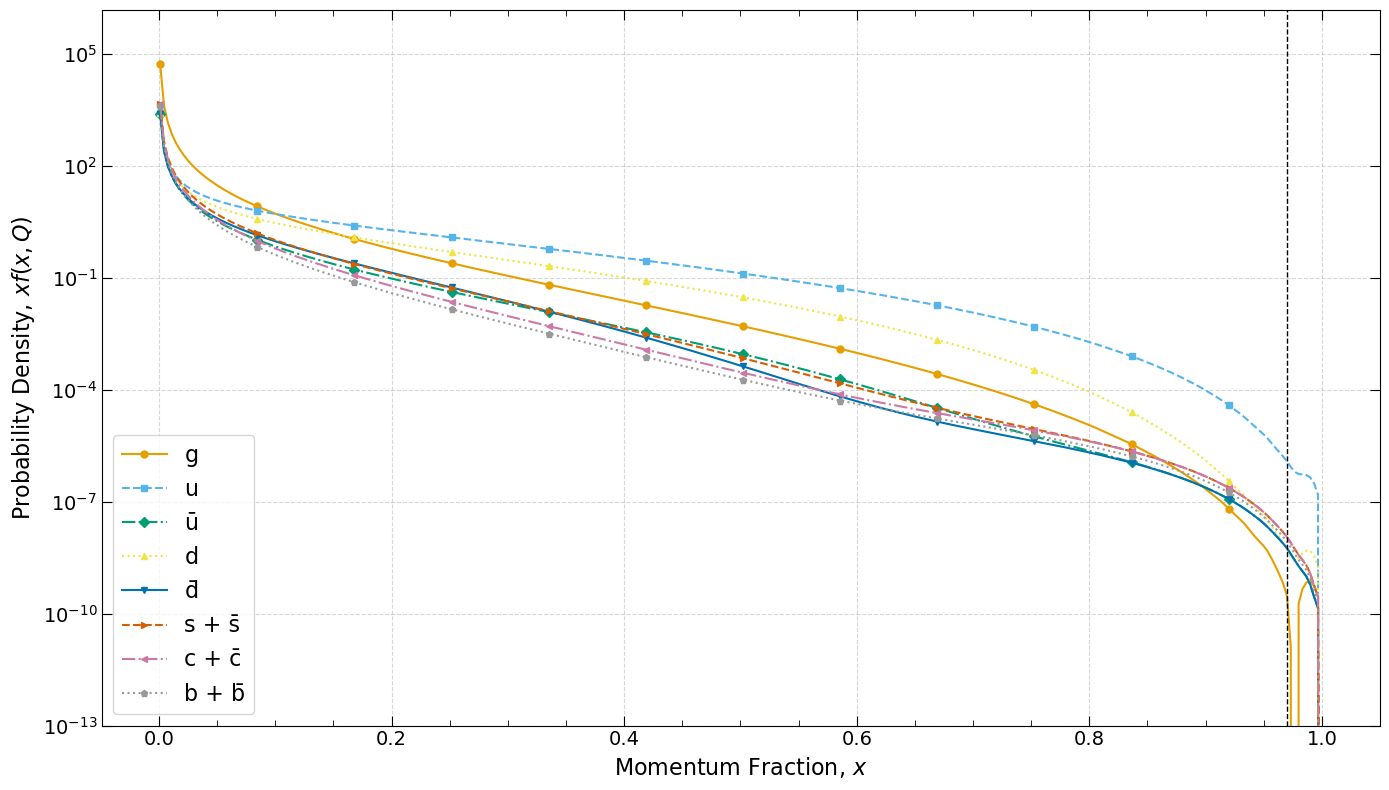

In [12]:
# Grouped partons (gluons separate, u/d separate, others combined)
parton_groups = {
    "g": [21],
    "u": [2],
    "ū": [-2],
    "d": [1],
    "d̄": [-1],
    "s + s̄": [3, -3],
    "c + c̄": [4, -4],
    "b + b̄": [5, -5],
}

# Color-blind friendly palette (Tableau colors)
colors = [
    "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999"
]

# Different line styles and markers
line_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v", ">", "<", "p"]

# Q is a factorisation scale for the PDFs
def plot_pdf_at_Q(pdfset_name, Q_GeV, save_folder="Plots"):
    # Ensure the save folder exists
    os.makedirs(save_folder, exist_ok=True)

    pdf = lhapdf.mkPDF(pdfset_name, 0)  # central member
    x_vals = np.linspace(0.001, 1.0, 300)

    plt.figure(figsize=(14, 8))

    for i, (label, pids) in enumerate(parton_groups.items()):
        f_vals = np.zeros_like(x_vals)
        for pid in pids:
            f_vals += np.array([pdf.xfxQ(pid, x, Q_GeV) / x for x in x_vals])

        plt.plot(
            x_vals, f_vals,
            label=label,
            color=colors[i % len(colors)],
            linestyle=line_styles[i % len(line_styles)],
            marker=markers[i % len(markers)],
            markevery=25,   # place markers every N points
            linewidth=1.5,
            markersize=5
        )

    plt.yscale("log")
    plt.xlabel(r"Momentum Fraction, $x$", fontsize = 16)
    plt.ylabel(r"Probability Density, $x f(x,Q)$", fontsize = 16)
    #plt.title(f"PDF distributions at Q = {Q_GeV/1000:.0f} TeV ({pdfset_name})", fontsize = 14)

    # Axis ticks
    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.minorticks_on()

    # Major ticks: all sides, pointing inward
    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=7,
        labelsize=14,
    )

    # Minor ticks: all sides, pointing inward
    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=4,
    )

    plt.grid(True, which="major", linestyle="--", alpha=0.5)

    # Set y-axis lower limit and add vertical line 
    plt.ylim(bottom=1e-13)
    plt.axvline(x=0.97, color="black", linestyle="--", linewidth=1)

    plt.legend(loc="lower left", fontsize=16)
    plt.tight_layout()

    # Save figure
    filename = f"{save_folder}/PDFs/{pdfset_name}_{int(Q_GeV/1000)}TeV.png"
    # plt.savefig(filename, dpi=300)
    # print(f"Saved {filename}")

    # Display figure
    plt.show()

# Example usage
plot_pdf_at_Q("cteq6l1", 1000)
plot_pdf_at_Q("cteq6l1", 10000)
# plot_pdf_at_Q("cteq66", 9000)
# plot_pdf_at_Q("CT10", 9000)

Saved Plots/PDFs/Convolution.png


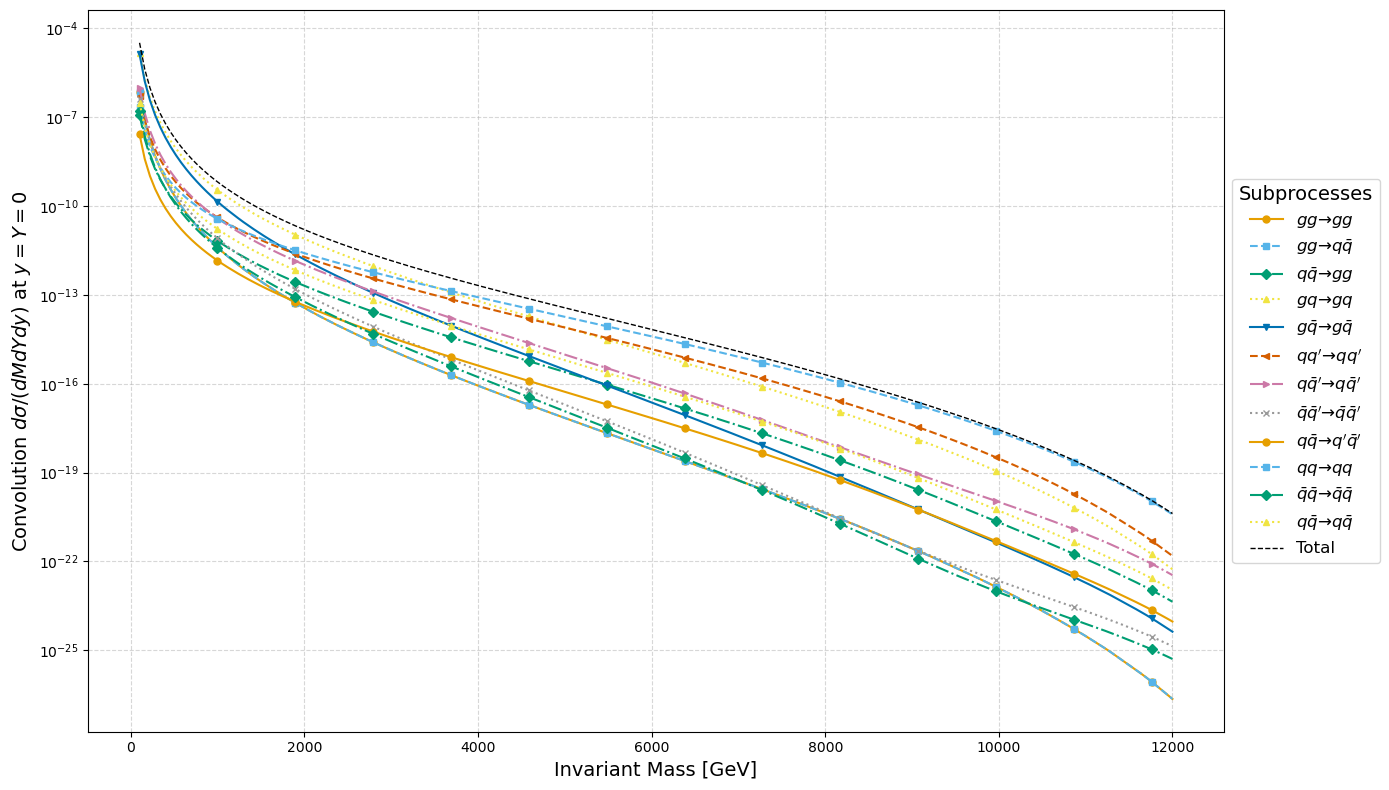

In [ ]:
# --- Plotting style setup ---
# Color-blind friendly palette (Okabe-Ito)
cbf_colors = [
    "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00",
    "#CC79A7", "#999999"
]

# Line styles and markers to distinguish curves
line_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v", "<", ">", "x"]

M_vals = np.linspace(0.1, 12.0, 200) * cfg.TeV2GeV
s = cfg.s
PDF = fns.PDF
total_dSigma = np.zeros_like(M_vals)

if combined_plot:
    plt.figure(figsize=(14, 8))

for idx, (pretty_name, subprocess, MSquaredFunc, default_IDs) in enumerate(Subprocesses):
    dSigma = []

    for i, M in enumerate(M_vals):
        if sum_flavours:
            sigma_sum = 0.0
            combinations = fns.subprocess_combinations(subprocess)
            for ID1, ID2, func in combinations:
                PDF_val, _, _ = fns.QCD(
                    parameters=[0, 0],
                    M=M,
                    ID1=ID1,
                    ID2=ID2,
                    s=s,
                    PDF=PDF,
                    MinMass=M_vals[0],
                    MaxMass=M_vals[-1],
                    MSquaredFunc=func
                )
                sigma_sum += PDF_val
            dSigma.append(sigma_sum)
            total_dSigma[i] += sigma_sum
        else:
            ID1, ID2 = default_IDs
            PDF_val, _, _ = fns.QCD(
                parameters=[0, 0],
                M=M,
                ID1=ID1,
                ID2=ID2,
                s=s,
                PDF=PDF,
                MinMass=M_vals[0],
                MaxMass=M_vals[-1],
                MSquaredFunc=MSquaredFunc
            )
            dSigma.append(PDF_val)
            total_dSigma[i] += PDF_val

    # --- Plotting each subprocess ---
    color = cbf_colors[idx % len(cbf_colors)]
    ls = line_styles[idx % len(line_styles)]
    marker = markers[idx % len(markers)]

    if combined_plot:
        plt.plot(
            M_vals, dSigma,
            label=pretty_name,
            color=color,
            linestyle=ls,
            marker=marker,
            markevery=15,
            linewidth=1.5,
            markersize=5
        )
    else:
        plt.figure(figsize=(10, 5))
        plt.plot(
            M_vals, dSigma,
            label=pretty_name,
            color=color,
            linestyle=ls,
            marker=marker,
            markevery=15,
            linewidth=1.5,
            markersize=5
        )
        plt.yscale('log')
        plt.xlabel("Invariant Mass [GeV]")
        ylabel = (r"Convolution $d\sigma/(dM dY dy)$")
        plt.ylabel(ylabel)
        plt.title(f"Differential Cross Section: {pretty_name}")
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.legend()
        plt.show()

# --- Total if combined ---
if combined_plot:
    plt.plot(M_vals, total_dSigma, 'k--', linewidth=1, label="Total")
    plt.yscale('log')
    plt.xlabel("Invariant Mass [GeV]", fontsize=14)
    plt.ylabel(r"Convolution $d\sigma/(dM dY dy)$ at $y = Y = 0$", fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        fontsize=12,
        title="Subprocesses",
        title_fontsize=14
    )
    plt.tight_layout()

    # Save **before** show
    filename = f"Plots/PDFs/Convolution.png"
    # plt.savefig(filename, dpi=300)
    print(f"Saved {filename}")

    plt.show()

### Two Ways Other Ways to Integrate

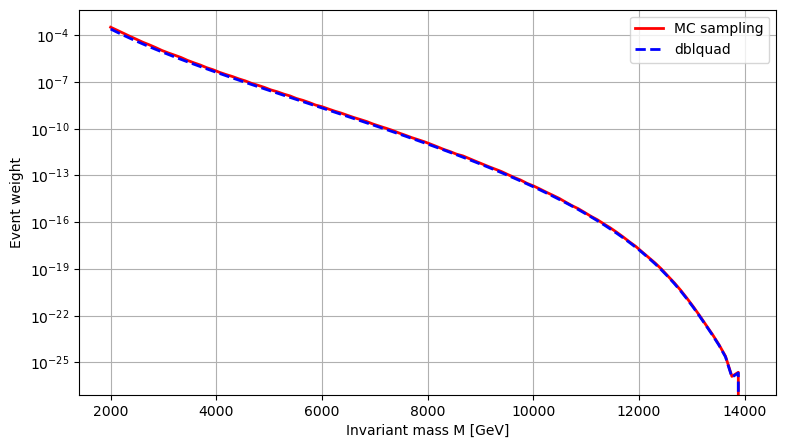

In [26]:
from scipy.integrate import dblquad

Mmin, Mmax = 2000, 14000   # GeV
Npoints = 100
ID1, ID2 = 21, 21         # gg -> gg
s = 14000**2              # sqrt(s) 
yMax = 2.5
PDF = fns.PDF      
MSquaredFunc = fns.M2_gg_gg    # matrix element for the subprocess
N_events = 10000               # same as used in generate_events

DeltaMass = (Mmax - Mmin) / N_events
scale_factor = 1e9 * 0.389379 * DeltaMass  # same as in your code

def MonteCarlo(Mmin, Mmax, Npoints, ID1, ID2, s, yMax, PDF, MSquaredFunc, scale):
    M_vals = np.linspace(Mmin, Mmax, Npoints)
    dsigma_dM = []

    for M in M_vals:
        tau = M**2 / s
        Ymax = min(np.log(1 / np.sqrt(tau)), yMax)

        # Monte Carlo integration over Y and y
        Nsample = 2000
        integrand_vals = []
        for _ in range(Nsample):
            Y = np.random.uniform(-Ymax, Ymax)
            y = np.random.uniform(-(yMax - abs(Y)), yMax - abs(Y))
            val, _, _ = fns.QCD([Y, y], M, ID1, ID2, s, PDF, Mmin, Mmax, MSquaredFunc)
            integrand_vals.append(val)
        avg = np.mean(integrand_vals)
        dYdy_range = (2*Ymax) * (2*(yMax - 0))  # integration volume
        dsigma_dM.append(avg * dYdy_range * scale)  # scale like event weights

    return M_vals, np.array(dsigma_dM)

def dblquad_int(M_vals, ID1, ID2, s, PDF, MinMass, MaxMass, yMax, MSquaredFunc, N_events):
    results = []
    DeltaMass = (MaxMass - MinMass) / N_events  # same as in generate_events

    for M in M_vals:
        Ymax = min(np.log(1/np.sqrt(M**2/s)), yMax)

        def integrand(y, Y):
            return fns.convolution((Y, y), M, ID1, ID2, s, PDF, MinMass, MaxMass, MSquaredFunc)

        val, _err = dblquad(
            integrand,
            -Ymax, Ymax,
            lambda Y: -(yMax - abs(Y)),
            lambda Y: +(yMax - abs(Y))
        )

        # Apply same weighting as generator: GeV^-2 → pb, then × bin width
        val *= 0.389379e9 * DeltaMass

        results.append(val)

    return np.array(results)

M_values, dsigma_scaled = MonteCarlo(Mmin, Mmax, Npoints, ID1, ID2, s, yMax, PDF, MSquaredFunc, scale_factor)

M_valuess = np.linspace(Mmin, Mmax, Npoints)
curve = dblquad_int(M_vals, ID1, ID2, s, fns.PDF, Mmin, Mmax, yMax, fns.M2_gg_gg, 1000*11)

# --- Overlay both theory curves ---
plt.figure(figsize=(9,5))
plt.plot(M_vals, dsigma_scaled, label="MC sampling", lw=2, color="red")
plt.plot(M_vals, curve, label="dblquad", lw=2, linestyle="--", color="blue")
plt.yscale("log")
plt.xlabel("Invariant mass M [GeV]")
plt.ylabel(r"d$\sigma$/dM [pb/GeV]")
#plt.title("Overlay of theory curves")
plt.grid(True)
plt.legend()
plt.show()

Saved Plots/PDFs/dsigmadM.png


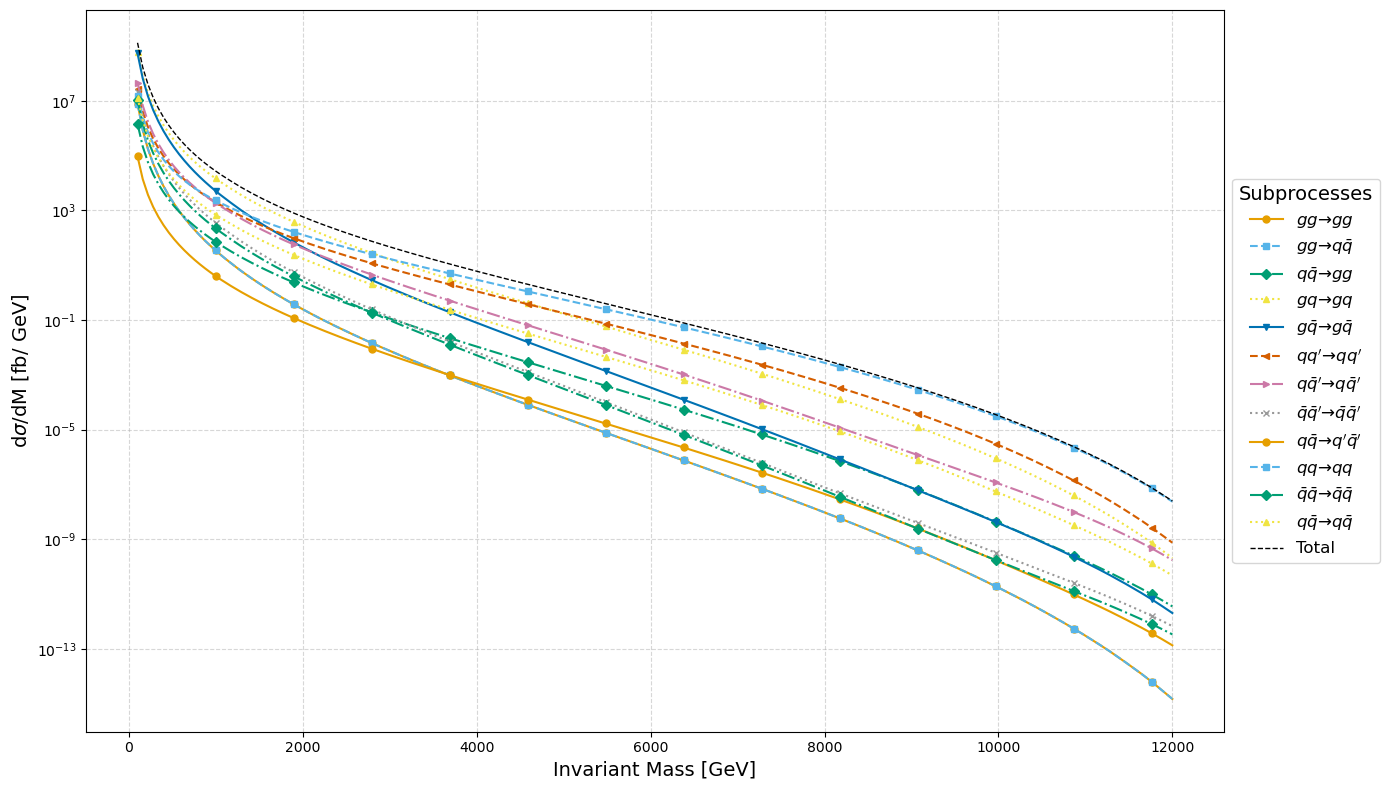

In [43]:
"""
This is just dσ?
"""

# Scale factor for units [GeV^-2 → fb] like in generator. multiply by 1e3 to get to fb
scale_factor = 0.389379e9 * 1e3   

total_dSigma = np.zeros_like(M_vals)

# --- Plotting style setup ---
# Color-blind friendly palette (Okabe-Ito)
cbf_colors = [
    "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00",
    "#CC79A7", "#999999"
]

# Line styles and markers
line_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v", "<", ">", "x"]

if combined_plot:
    plt.figure(figsize=(14, 8))

# Summing over each ID combination 
for idx, (pretty_name, subprocess, MSquaredFunc, default_IDs) in enumerate(Subprocesses):
    dSigma = []

    for i, M in enumerate(M_vals):
        tau = M**2 / s
        Ymax_local = min(np.log(1/np.sqrt(tau)), cfg.yMax)

        if sum_flavours:
            combinations = fns.subprocess_combinations(subprocess)
        else:
            combinations = [(*default_IDs, MSquaredFunc)]

        sigma_sum = 0.0
        for ID1, ID2, func in combinations:
            sigma_M = fns.Integrate(
                lambda *args: fns.convolution(*args, M_vals[0], M_vals[-1], func),
                (M, ID1, ID2, s, PDF),
                fns.MC, -Ymax_local, Ymax_local, cfg.yMax
            )
            sigma_sum += sigma_M

        sigma_sum *= scale_factor
        dSigma.append(sigma_sum)
        total_dSigma[i] += sigma_sum

    # --- Plotting each subprocess ---
    color = cbf_colors[idx % len(cbf_colors)]
    ls = line_styles[idx % len(line_styles)]
    marker = markers[idx % len(markers)]

    if combined_plot:
        plt.plot(
            M_vals, dSigma,
            label=pretty_name,
            color=color,
            linestyle=ls,
            marker=marker,
            markevery=15,
            linewidth=1.5,
            markersize=5
        )
    else:
        plt.figure(figsize=(10, 5))
        plt.plot(
            M_vals, dSigma,
            label=pretty_name,
            color=color,
            linestyle=ls,
            marker=marker,
            markevery=15,
            linewidth=1.5,
            markersize=5
        )
        plt.yscale('log')
        ylabel = (r"d$\sigma$ [pb]")
        plt.ylabel(ylabel)
        plt.xlabel("Invariant Mass [GeV]")
        plt.title(f"Differential Cross Section: {pretty_name}")
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.legend()
        plt.show()

# --- Total if combined ---
if combined_plot:
    plt.plot(M_vals, total_dSigma, 'k--', linewidth=1, label="Total")
    plt.yscale('log')
    plt.xlabel("Invariant Mass [GeV]", fontsize=14)
    plt.ylabel(r"d$\sigma$/dM [fb/ GeV]", fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        fontsize=12,
        title="Subprocesses",
        title_fontsize=14
    )
    plt.tight_layout()

    # --- Save figure ---
    filename = f"Plots/PDFs/dsigmadM.png"
    plt.savefig(filename, dpi=300)
    print(f"Saved {filename}")

    # --- Show plot ---
    plt.show()